**Data Preparation and Cleaning**

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("/kaggle/input/netflix-titlescsv/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.isnull().sum()                #handle missing values 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')

In [6]:
df.dropna(subset=['date_added'], inplace = True)

In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')

In [8]:
df['year_added'] = df['date_added'].dt.year

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          7972 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8793 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
 12  year_added    8709 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 962.2+ KB


**Exploratorty Analysis and Visualization**

# Visualization 1: Count of Movies vs TV Shows

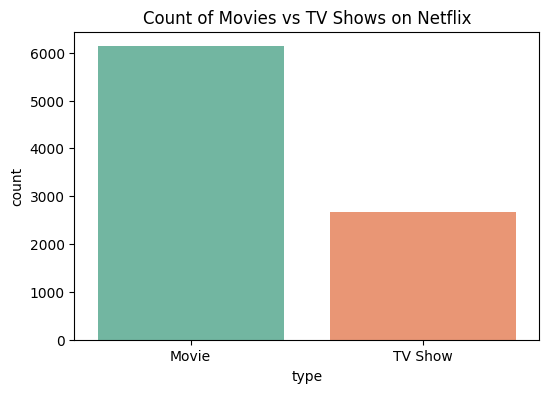

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title("Count of Movies vs TV Shows on Netflix")
plt.show()

# Visualization 2: Top 10 countries with most Netflix content

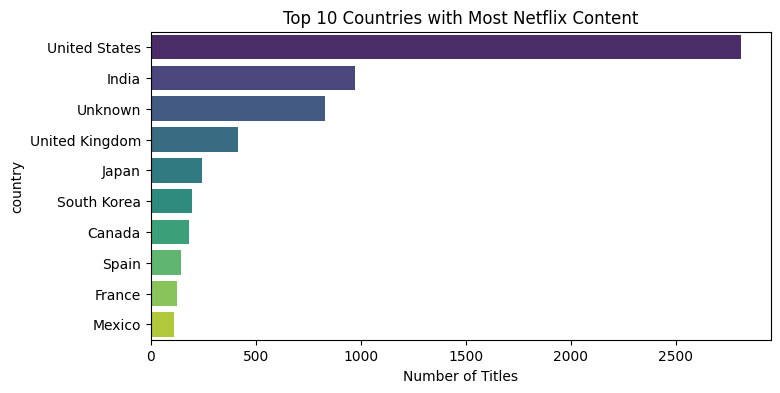

In [11]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Number of Titles")
plt.show()

# Visualization 3: Distribution of Release Years

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


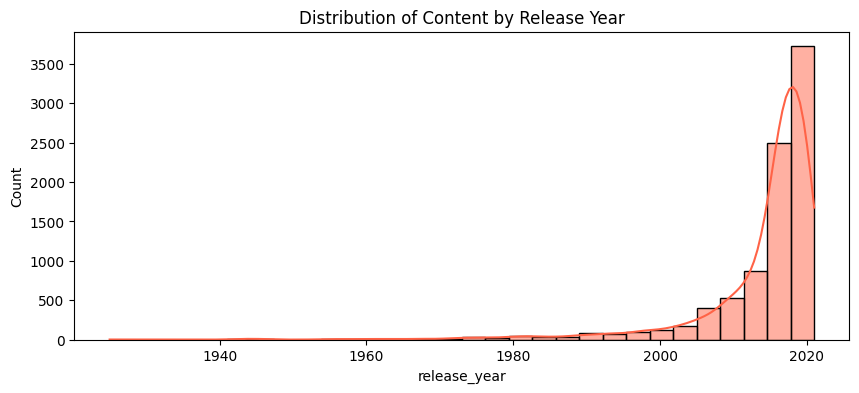

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(df['release_year'], bins=30, kde=True, color='tomato')
plt.title("Distribution of Content by Release Year")
plt.show()

# Visualization 4: Most common genres (listed_in)
from collections import Counter

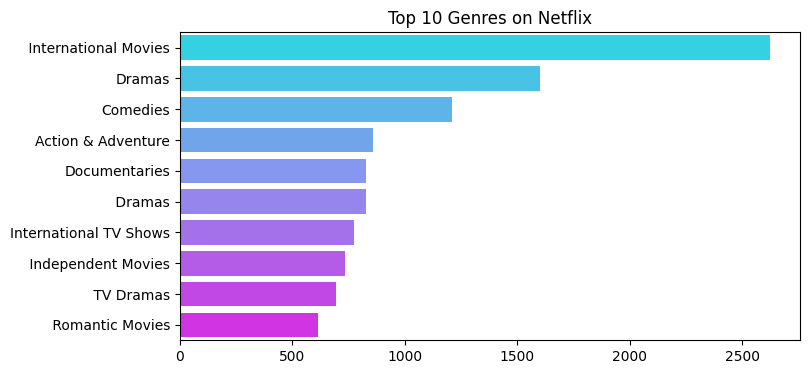

In [13]:
genre_list = df['listed_in'].str.split(',').sum()
top_genres = pd.Series(genre_list).value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='cool')
plt.title("Top 10 Genres on Netflix")
plt.show()

# Questions and Asnwers 

In [14]:
# Q1: What type of content (Movies/TV Shows) dominates Netflix?
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [15]:
# Q2: Which country has produced the most Netflix titles?
df['country'].value_counts().head(1)

country
United States    2812
Name: count, dtype: int64

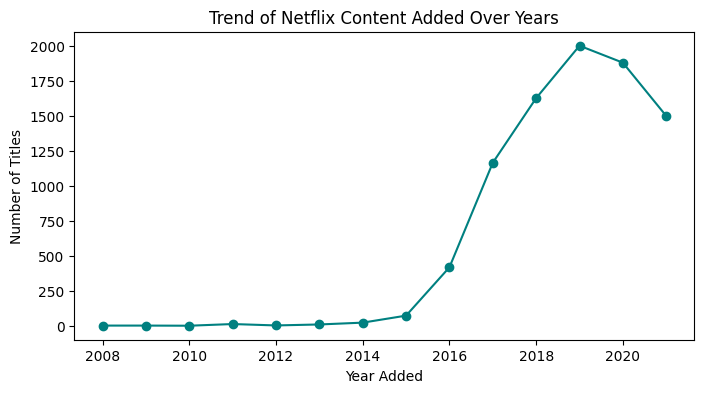

In [16]:
# Q3: What is the trend of content added over the years?
content_trend = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.plot(content_trend.index, content_trend.values, marker='o', color='teal')
plt.title("Trend of Netflix Content Added Over Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

In [17]:
# Q4: What are the top 5 most common ratings on Netflix?
df['rating'].value_counts().head(5)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64

# Summary & Interference 

1. Netflix hosts more movies than TV Shows.
2. The United States contributes the most titles
3. the number of titles added increased steadily till 2019, then dropped slightly
4. Dramas, cvomedies, and Documentaries are the most popular genres
5. This analysis gives an overview of Netflix's evolving catalog and helps identify user content trends.